# NCA spatial cross-validation: 2 km vs 5 km blocks

This notebook compares the two POLARIS representations under the validation design that is most relevant to spatial mapping:

- **Z only** — 45 annual z-scored IA45 optical features
- **Z + POLARIS 18D** — the original 18 depth-explicit texture predictors
- **Z + POLARIS 7D** — the new seven 0–30 cm depth-integrated edaphic predictors
- POLARIS-only versions are retained as diagnostics

Two block sizes are evaluated:

\[
2\ \mathrm{km}
\qquad\text{and}\qquad
5\ \mathrm{km}.
\]

Within each block scale, entire spatial blocks are assigned to one of five folds.  
The same fold assignment is reused for every representation, giving paired comparisons.

The default analysis uses the full common support domain (~479 field observations), which should yield roughly 80–100 test observations per fold. Set `FILTER_TO_TRUE_NCA = True` if the estimand should instead be restricted to the true NCA boundary.

Important: square blocks prevent observations **within the same block** from appearing in both train and test, but adjacent train/test blocks can touch. The notebook therefore also reports each held-out observation's nearest training-point distance.

In [6]:
# =============================================================================
# 0. IMPORTS / CONFIGURATION
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)
from sklearn.neighbors import NearestNeighbors

try:
    import geopandas as gpd
except ImportError:
    gpd = None


pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 280)


# -----------------------------------------------------------------------------
# EXISTING MODEL OUTPUTS
# -----------------------------------------------------------------------------

OLD_18D_DIR = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POLARIS"
)

NEW_7D_DIR = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POLARIS_0_30Weighted"
)

OLD_DATASET = (
    OLD_18D_DIR
    / "FieldVeg_AnnualZScore_POLARIS_common_ML_dataset.csv"
)

NEW_DATASET = (
    NEW_7D_DIR
    / "FieldVeg_AnnualZScore_POLARIS_common_ML_dataset.csv"
)


# -----------------------------------------------------------------------------
# OUTPUT
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path(
    r"C:\NCA_DATA\Analysis\SpatialCV_POLARIS_18D_vs_7D"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# -----------------------------------------------------------------------------
# SPATIAL CV
# -----------------------------------------------------------------------------

BLOCK_SIZES_M = [
    2000,
    5000,
]

N_SPLITS = 5
RANDOM_STATE = 42

# Full support domain gives ~96 observations/fold for n~479.
# Change to True to evaluate only observations inside the true NCA.
FILTER_TO_TRUE_NCA = False

TRUE_NCA_SHP = Path(
    r"C:\NCA_DATA\templates\SRBOP_NCA_extent_26911.shp"
)


# -----------------------------------------------------------------------------
# MODELS
#
# RF is the mapping model and the principal comparison.
# Set RUN_ALL_MODELS=True for the same three-model diagnostic used previously.
# -----------------------------------------------------------------------------

RUN_ALL_MODELS = False

MODEL_FOR_PRIMARY_COMPARISON = "random_forest"

VEG_PARENT_CODES = list(range(1, 9))
VEG_CLASSES = [
    f"VEG::{i}"
    for i in VEG_PARENT_CODES
]

print("18D dataset:", OLD_DATASET)
print("7D dataset: ", NEW_DATASET)
print("Output:      ", OUTPUT_DIR)

18D dataset: C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POLARIS\FieldVeg_AnnualZScore_POLARIS_common_ML_dataset.csv
7D dataset:  C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POLARIS_0_30Weighted\FieldVeg_AnnualZScore_POLARIS_common_ML_dataset.csv
Output:       C:\NCA_DATA\Analysis\SpatialCV_POLARIS_18D_vs_7D


## 1. Load and align the 18D and 7D datasets

The representation comparison must use exactly the same field observations.  
The notebook intersects the datasets on `(PlotID, Year)`, verifies labels and coordinates, and verifies that the 45 optical z-score features are numerically identical.

In [7]:
# =============================================================================
# 1. LOAD + ALIGN DATASETS
# =============================================================================

for path in [
    OLD_DATASET,
    NEW_DATASET,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required dataset not found:\n{path}"
        )


old = pd.read_csv(
    OLD_DATASET,
    low_memory=False,
)

new = pd.read_csv(
    NEW_DATASET,
    low_memory=False,
)


KEY_COLS = [
    "PlotID",
    "Year",
]

META_COLS = [
    "parent_cluster",
    "Easting",
    "Northing",
]


for name, df in [
    ("18D", old),
    ("7D", new),
]:
    missing = [
        c
        for c in KEY_COLS + META_COLS
        if c not in df.columns
    ]

    if missing:
        raise KeyError(
            f"{name} dataset is missing columns: {missing}"
        )

    if df.duplicated(
        KEY_COLS
    ).any():
        raise ValueError(
            f"{name} dataset contains duplicate PlotID-Year keys."
        )


old = old.set_index(
    KEY_COLS
).sort_index()

new = new.set_index(
    KEY_COLS
).sort_index()


common_index = old.index.intersection(
    new.index
)

if len(common_index) == 0:
    raise RuntimeError(
        "No common PlotID-Year observations between 18D and 7D datasets."
    )


old_only = old.index.difference(
    new.index
)

new_only = new.index.difference(
    old.index
)


print(
    f"18D rows: {len(old):,}"
)

print(
    f"7D rows:  {len(new):,}"
)

print(
    f"Common:   {len(common_index):,}"
)

print(
    f"18D only: {len(old_only):,}"
)

print(
    f"7D only:  {len(new_only):,}"
)


old = old.loc[
    common_index
].copy()

new = new.loc[
    common_index
].copy()


# -----------------------------------------------------------------------------
# METADATA QA
# -----------------------------------------------------------------------------

if not np.array_equal(
    old[
        "parent_cluster"
    ].astype(int).to_numpy(),
    new[
        "parent_cluster"
    ].astype(int).to_numpy(),
):
    raise ValueError(
        "Parent labels differ between the two datasets."
    )


for coord in [
    "Easting",
    "Northing",
]:

    if not np.allclose(
        old[
            coord
        ].astype(float).to_numpy(),
        new[
            coord
        ].astype(float).to_numpy(),
        equal_nan=False,
    ):

        raise ValueError(
            f"{coord} differs between 18D and 7D datasets."
        )


# -----------------------------------------------------------------------------
# FEATURE COLUMNS
# -----------------------------------------------------------------------------

z_cols_old = [
    c
    for c in old.columns
    if c.startswith(
        "z__"
    )
]

z_cols_new = [
    c
    for c in new.columns
    if c.startswith(
        "z__"
    )
]

p18_cols = [
    c
    for c in old.columns
    if c.startswith(
        "POLARIS__"
    )
]

p7_cols = [
    c
    for c in new.columns
    if c.startswith(
        "POLARIS__"
    )
]


if z_cols_old != z_cols_new:
    raise ValueError(
        "18D and 7D datasets do not contain the same ordered z-feature columns."
    )


if len(
    z_cols_old
) != 45:
    raise ValueError(
        f"Expected 45 z features; found {len(z_cols_old)}."
    )


if len(
    p18_cols
) != 18:
    raise ValueError(
        f"Expected 18 original POLARIS features; found {len(p18_cols)}."
    )


if len(
    p7_cols
) != 7:
    raise ValueError(
        f"Expected 7 condensed POLARIS features; found {len(p7_cols)}."
    )


if not np.allclose(
    old[
        z_cols_old
    ].to_numpy(
        dtype=np.float64
    ),
    new[
        z_cols_new
    ].to_numpy(
        dtype=np.float64
    ),
):
    raise ValueError(
        "Z features differ numerically between the 18D and 7D datasets."
    )


analysis = new[
    META_COLS
].copy()

analysis[
    "PlotID"
] = [
    str(idx[0])
    for idx in analysis.index
]

analysis[
    "Year"
] = [
    int(idx[1])
    for idx in analysis.index
]


# -----------------------------------------------------------------------------
# OPTIONAL TRUE-NCA FILTER
# -----------------------------------------------------------------------------

if FILTER_TO_TRUE_NCA:

    if gpd is None:
        raise ImportError(
            "geopandas is required for FILTER_TO_TRUE_NCA=True."
        )

    if not TRUE_NCA_SHP.exists():
        raise FileNotFoundError(
            f"True NCA shapefile not found:\n{TRUE_NCA_SHP}"
        )

    nca = gpd.read_file(
        TRUE_NCA_SHP
    )

    points = gpd.GeoDataFrame(
        analysis.copy(),
        geometry=gpd.points_from_xy(
            analysis[
                "Easting"
            ],
            analysis[
                "Northing"
            ],
        ),
        crs=nca.crs,
    )

    nca_union = nca.geometry.union_all()

    inside = points.geometry.map(
        nca_union.covers
    ).to_numpy()

    analysis = analysis.loc[
        inside
    ].copy()

    old = old.loc[
        analysis.index
    ].copy()

    new = new.loc[
        analysis.index
    ].copy()

    print(
        f"Rows retained inside true NCA: {len(analysis):,}"
    )


# -----------------------------------------------------------------------------
# MATRICES
# -----------------------------------------------------------------------------

X_z = old[
    z_cols_old
].to_numpy(
    dtype=np.float64
)

X_p18 = old[
    p18_cols
].to_numpy(
    dtype=np.float64
)

X_p7 = new[
    p7_cols
].to_numpy(
    dtype=np.float64
)


REPRESENTATIONS = {
    "z": X_z,

    "polaris_18d": X_p18,

    "polaris_7d": X_p7,

    "z_plus_polaris_18d": np.hstack(
        [
            X_z,
            X_p18,
        ]
    ),

    "z_plus_polaris_7d": np.hstack(
        [
            X_z,
            X_p7,
        ]
    ),
}


y = (
    "VEG::"
    + analysis[
        "parent_cluster"
    ].astype(
        int
    ).astype(
        str
    )
).to_numpy()


coords = analysis[
    [
        "Easting",
        "Northing",
    ]
].to_numpy(
    dtype=np.float64
)


years = analysis[
    "Year"
].astype(
    int
).to_numpy()


print(
    "\nFeature dimensions:"
)

for name, X in REPRESENTATIONS.items():
    print(
        f"  {name:24s}: {X.shape}"
    )


print(
    "\nYear counts:"
)

display(
    analysis[
        "Year"
    ].value_counts()
    .sort_index()
    .rename(
        "n"
    )
    .to_frame()
)


print(
    "\nParent counts:"
)

display(
    analysis[
        "parent_cluster"
    ].value_counts()
    .sort_index()
    .rename(
        "n"
    )
    .to_frame()
)

18D rows: 479
7D rows:  479
Common:   479
18D only: 0
7D only:  0

Feature dimensions:
  z                       : (479, 45)
  polaris_18d             : (479, 18)
  polaris_7d              : (479, 7)
  z_plus_polaris_18d      : (479, 63)
  z_plus_polaris_7d       : (479, 52)

Year counts:


,n
Year,
2016,255
2018,106
2025,118



Parent counts:


,n
parent_cluster,
1,83
2,59
3,78
4,82
5,74
6,51
7,32
8,20


## 2. Compare the already-saved non-spatial validation results

This is diagnostic only. It compares the **increment from Z to Z+POLARIS** in the old and new runs using their saved grouped-OOF and LOYO outputs.

The spatial CV below is the more relevant criterion for selecting the representation for spatial mapping.

In [8]:
# =============================================================================
# 2. PRIOR VALIDATION COMPARISON: 18D VS 7D
# =============================================================================

def load_if_exists(
    path,
):

    if path.exists():

        return pd.read_csv(
            path
        )

    print(
        "Not found; skipping:",
        path,
    )

    return None


old_oof = load_if_exists(
    OLD_18D_DIR
    / "representation_groupedOOF_pooled_metrics.csv"
)

new_oof = load_if_exists(
    NEW_7D_DIR
    / "representation_groupedOOF_pooled_metrics.csv"
)

old_loyo = load_if_exists(
    OLD_18D_DIR
    / "representation_leaveYearOut.csv"
)

new_loyo = load_if_exists(
    NEW_7D_DIR
    / "representation_leaveYearOut.csv"
)


# =============================================================================
# HELPER: GAIN FROM Z -> Z + POLARIS
# =============================================================================

def z_to_zp_gain(
    df,
    metric_cols,
    extra_keys=None,
    model=MODEL_FOR_PRIMARY_COMPARISON,
):
    """
    Calculate:

        metric(Z + POLARIS) - metric(Z)

    for one model.

    If extra_keys is None / empty:
        returns one pooled row.

    If extra_keys contains columns such as held_out_year:
        returns one row per unique key combination.
    """

    if extra_keys is None:

        extra_keys = []


    required_cols = (
        [
            "representation",
            "model",
        ]
        + list(
            extra_keys
        )
        + list(
            metric_cols
        )
    )


    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]


    if missing_cols:

        raise KeyError(
            "Input validation table is missing columns:\n"
            f"{missing_cols}"
        )


    # -------------------------------------------------------------------------
    # KEEP ONLY THE MODEL + REPRESENTATIONS WE NEED
    # -------------------------------------------------------------------------

    x = df.loc[
        df[
            "model"
        ].eq(
            model
        )
        & df[
            "representation"
        ].isin(
            [
                "z",
                "z_plus_polaris",
            ]
        )
    ].copy()


    if x.empty:

        raise ValueError(
            f"No rows found for model={model!r} "
            "with representations 'z' and 'z_plus_polaris'."
        )


    # =========================================================================
    # CASE 1: POOLED METRICS — NO GROUPING KEYS
    # =========================================================================

    if len(
        extra_keys
    ) == 0:

        z_rows = x.loc[
            x[
                "representation"
            ].eq(
                "z"
            )
        ]


        zp_rows = x.loc[
            x[
                "representation"
            ].eq(
                "z_plus_polaris"
            )
        ]


        if len(
            z_rows
        ) != 1:

            raise ValueError(
                "Expected exactly one pooled Z row "
                f"for model={model!r}; found {len(z_rows)}."
            )


        if len(
            zp_rows
        ) != 1:

            raise ValueError(
                "Expected exactly one pooled Z+POLARIS row "
                f"for model={model!r}; found {len(zp_rows)}."
            )


        z_row = z_rows.iloc[
            0
        ]

        zp_row = zp_rows.iloc[
            0
        ]


        result = {}


        for metric in metric_cols:

            result[
                f"z_{metric}"
            ] = float(
                z_row[
                    metric
                ]
            )


            result[
                f"z_plus_polaris_{metric}"
            ] = float(
                zp_row[
                    metric
                ]
            )


            result[
                f"gain_{metric}"
            ] = (
                float(
                    zp_row[
                        metric
                    ]
                )
                -
                float(
                    z_row[
                        metric
                    ]
                )
            )


        return pd.DataFrame(
            [
                result
            ]
        )


    # =========================================================================
    # CASE 2: GROUPED METRICS — E.G. LEAVE-ONE-YEAR-OUT
    # =========================================================================

    z = (
        x.loc[
            x[
                "representation"
            ].eq(
                "z"
            ),
            extra_keys
            + metric_cols,
        ]
        .copy()
    )


    zp = (
        x.loc[
            x[
                "representation"
            ].eq(
                "z_plus_polaris"
            ),
            extra_keys
            + metric_cols,
        ]
        .copy()
    )


    # Rename score columns before joining.
    z = z.rename(
        columns={
            metric:
                f"z_{metric}"
            for metric in metric_cols
        }
    )


    zp = zp.rename(
        columns={
            metric:
                f"z_plus_polaris_{metric}"
            for metric in metric_cols
        }
    )


    merged = z.merge(
        zp,
        on=extra_keys,
        how="inner",
        validate="one_to_one",
    )


    if merged.empty:

        raise ValueError(
            "Could not align Z and Z+POLARIS rows "
            f"using keys {extra_keys}."
        )


    for metric in metric_cols:

        merged[
            f"gain_{metric}"
        ] = (
            merged[
                f"z_plus_polaris_{metric}"
            ]
            -
            merged[
                f"z_{metric}"
            ]
        )


    return merged


# =============================================================================
# METRICS
# =============================================================================

METRICS = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
]


# =============================================================================
# GROUPED OOF COMPARISON
# =============================================================================

if (
    old_oof is not None
    and new_oof is not None
):

    old_gain = (
        z_to_zp_gain(
            old_oof,
            METRICS,
        )
        .assign(
            polaris_representation="18D"
        )
    )


    new_gain = (
        z_to_zp_gain(
            new_oof,
            METRICS,
        )
        .assign(
            polaris_representation="7D"
        )
    )


    prior_oof_gain = pd.concat(
        [
            old_gain,
            new_gain,
        ],
        ignore_index=True,
    )


    # Put design column first.
    prior_oof_gain = prior_oof_gain[
        [
            "polaris_representation",
        ]
        + [
            col
            for col in prior_oof_gain.columns
            if col
            != "polaris_representation"
        ]
    ]


    print(
        "\nGrouped OOF: RF gain from adding POLARIS"
    )


    display(
        prior_oof_gain.round(
            4
        )
    )


# =============================================================================
# LEAVE-ONE-YEAR-OUT COMPARISON
# =============================================================================

if (
    old_loyo is not None
    and new_loyo is not None
):

    old_gain_loyo = (
        z_to_zp_gain(
            old_loyo,
            METRICS,
            extra_keys=[
                "held_out_year",
            ],
        )
        .assign(
            polaris_representation="18D"
        )
    )


    new_gain_loyo = (
        z_to_zp_gain(
            new_loyo,
            METRICS,
            extra_keys=[
                "held_out_year",
            ],
        )
        .assign(
            polaris_representation="7D"
        )
    )


    prior_loyo_gain = pd.concat(
        [
            old_gain_loyo,
            new_gain_loyo,
        ],
        ignore_index=True,
    )


    prior_loyo_gain = prior_loyo_gain[
        [
            "held_out_year",
            "polaris_representation",
        ]
        + [
            col
            for col in prior_loyo_gain.columns
            if col not in [
                "held_out_year",
                "polaris_representation",
            ]
        ]
    ]


    prior_loyo_gain = prior_loyo_gain.sort_values(
        [
            "held_out_year",
            "polaris_representation",
        ]
    ).reset_index(
        drop=True
    )


    print(
        "\nLOYO: RF gain from adding POLARIS"
    )


    display(
        prior_loyo_gain.round(
            4
        )
    )


Grouped OOF: RF gain from adding POLARIS


,polaris_representation,z_accuracy,z_plus_polaris_accuracy,gain_accuracy,z_balanced_accuracy,z_plus_polaris_balanced_accuracy,gain_balanced_accuracy,z_macro_f1,z_plus_polaris_macro_f1,gain_macro_f1
0,18D,0.4864,0.5303,0.0438,0.4362,0.4703,0.0341,0.4469,0.4801,0.0332
1,7D,0.4864,0.5094,0.0230,0.4362,0.4530,0.0168,0.4469,0.4620,0.0151



LOYO: RF gain from adding POLARIS


,held_out_year,polaris_representation,z_accuracy,z_balanced_accuracy,z_macro_f1,z_plus_polaris_accuracy,z_plus_polaris_balanced_accuracy,z_plus_polaris_macro_f1,gain_accuracy,gain_balanced_accuracy,gain_macro_f1
0,2016,18D,0.3412,0.2848,0.2792,0.4039,0.3521,0.3637,0.0627,0.0673,0.0845
1,2016,7D,0.3412,0.2848,0.2792,0.3529,0.3073,0.3149,0.0118,0.0225,0.0357
2,2018,18D,0.3113,0.2719,0.2433,0.3585,0.3024,0.2851,0.0472,0.0305,0.0418
3,2018,7D,0.3113,0.2719,0.2433,0.3302,0.2796,0.2567,0.0189,0.0077,0.0134
4,2025,18D,0.3305,0.3746,0.2971,0.3983,0.4797,0.4166,0.0678,0.1051,0.1195
5,2025,7D,0.3305,0.3746,0.2971,0.3390,0.3950,0.3111,0.0085,0.0204,0.0140


## 3. Construct 2 km and 5 km spatial blocks

Blocks use a fixed projected origin:

\[
b_x=\left\lfloor \frac{x}{L}\right\rfloor,
\qquad
b_y=\left\lfloor \frac{y}{L}\right\rfloor.
\]

This makes block membership reproducible and independent of the sampled bounding box.

Five folds are created with `StratifiedGroupKFold`, where:

- **group** = spatial block;
- preferred stratification label = `Year × parent state`;
- if any year-state stratum occupies fewer than five unique blocks, the code falls back to stratifying by parent state only.

No spatial block can appear in both train and test for a given fold.

In [9]:
# =============================================================================
# 3. SPATIAL BLOCKS + FOLDS
# =============================================================================

def spatial_block_ids(
    east,
    north,
    block_size_m,
):

    bx = np.floor(
        east
        / float(
            block_size_m
        )
    ).astype(
        np.int64
    )

    by = np.floor(
        north
        / float(
            block_size_m
        )
    ).astype(
        np.int64
    )

    return np.array(
        [
            f"{block_size_m}_{x}_{y}"
            for x, y in zip(
                bx,
                by,
            )
        ],
        dtype=object,
    )


def choose_stratification_target(
    block_ids,
):

    combined = np.array(
        [
            f"{year}__{label}"
            for year, label in zip(
                years,
                y,
            )
        ],
        dtype=object,
    )


    tmp = pd.DataFrame(
        {
            "stratum": combined,
            "block": block_ids,
        }
    )

    unique_blocks_per_stratum = (
        tmp.drop_duplicates()
        .groupby(
            "stratum"
        )[
            "block"
        ]
        .nunique()
    )


    if (
        unique_blocks_per_stratum.min()
        >= N_SPLITS
    ):

        return (
            combined,
            "Year × parent",
        )


    return (
        y.copy(),
        "parent only",
    )


SPATIAL_SPLITS = {}
fold_assignment_records = []
fold_qa_records = []


for block_size in BLOCK_SIZES_M:

    block_ids = spatial_block_ids(
        coords[
            :,
            0
        ],
        coords[
            :,
            1
        ],
        block_size,
    )


    strat_y, strat_name = choose_stratification_target(
        block_ids
    )


    cv = StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )


    splits = list(
        cv.split(
            X_z,
            strat_y,
            groups=block_ids,
        )
    )


    SPATIAL_SPLITS[
        block_size
    ] = {
        "block_ids": block_ids,
        "splits": splits,
        "stratification": strat_name,
    }


    fold_id = np.full(
        len(
            analysis
        ),
        -1,
        dtype=int,
    )


    for fold, (
        train_idx,
        test_idx,
    ) in enumerate(
        splits,
        start=1,
    ):

        fold_id[
            test_idx
        ] = fold


        # Verify no block leakage.
        train_blocks = set(
            block_ids[
                train_idx
            ]
        )

        test_blocks = set(
            block_ids[
                test_idx
            ]
        )

        overlap = (
            train_blocks
            & test_blocks
        )

        if overlap:
            raise RuntimeError(
                f"Block leakage detected for "
                f"{block_size} m fold {fold}: "
                f"{len(overlap)} overlapping blocks."
            )


        # Actual nearest training-point distance.
        nn = NearestNeighbors(
            n_neighbors=1,
            metric="euclidean",
        )

        nn.fit(
            coords[
                train_idx
            ]
        )

        distances, _ = nn.kneighbors(
            coords[
                test_idx
            ]
        )

        distances = distances[
            :,
            0
        ]


        fold_qa_records.append(
            {
                "block_size_m": block_size,
                "fold": fold,
                "stratification": strat_name,
                "n_train": len(
                    train_idx
                ),
                "n_test": len(
                    test_idx
                ),
                "n_train_blocks": len(
                    train_blocks
                ),
                "n_test_blocks": len(
                    test_blocks
                ),
                "nearest_train_distance_min_m": float(
                    distances.min()
                ),
                "nearest_train_distance_p10_m": float(
                    np.quantile(
                        distances,
                        0.10,
                    )
                ),
                "nearest_train_distance_median_m": float(
                    np.median(
                        distances
                    )
                ),
                "nearest_train_distance_mean_m": float(
                    distances.mean()
                ),
            }
        )


    if np.any(
        fold_id < 1
    ):
        raise RuntimeError(
            f"Not every observation received a fold for {block_size} m."
        )


    for i in range(
        len(
            analysis
        )
    ):

        fold_assignment_records.append(
            {
                "PlotID": analysis.iloc[
                    i
                ][
                    "PlotID"
                ],
                "Year": int(
                    analysis.iloc[
                        i
                    ][
                        "Year"
                    ]
                ),
                "parent_cluster": int(
                    analysis.iloc[
                        i
                    ][
                        "parent_cluster"
                    ]
                ),
                "Easting": float(
                    coords[
                        i,
                        0
                    ]
                ),
                "Northing": float(
                    coords[
                        i,
                        1
                    ]
                ),
                "block_size_m": block_size,
                "block_id": block_ids[
                    i
                ],
                "fold": int(
                    fold_id[
                        i
                    ]
                ),
            }
        )


fold_qa = pd.DataFrame(
    fold_qa_records
)

fold_assignments = pd.DataFrame(
    fold_assignment_records
)


print(
    "Spatial fold QA:"
)

display(
    fold_qa.round(
        1
    )
)


fold_qa.to_csv(
    OUTPUT_DIR
    / "spatial_fold_QA.csv",
    index=False,
)

fold_assignments.to_csv(
    OUTPUT_DIR
    / "spatial_fold_assignments.csv",
    index=False,
)

Spatial fold QA:


,block_size_m,fold,stratification,n_train,n_test,n_train_blocks,n_test_blocks,nearest_train_distance_min_m,nearest_train_distance_p10_m,nearest_train_distance_median_m,nearest_train_distance_mean_m
0,2000,1,parent only,385,94,128,30,156.8,324.9,1313.8,1711.0
1,2000,2,parent only,389,90,126,32,164.3,292.9,1207.8,1272.9
2,2000,3,parent only,377,102,127,31,102.4,307.1,1379.6,1898.6
3,2000,4,parent only,373,106,125,33,132.5,369.4,1549.5,1731.9
4,2000,5,parent only,392,87,126,32,102.4,237.0,1145.7,2063.9
5,5000,1,parent only,386,93,60,14,306.4,946.7,3215.2,3486.1
6,5000,2,parent only,397,82,56,18,62.8,807.7,2990.7,3044.4
7,5000,3,parent only,389,90,63,11,62.8,359.7,1954.1,2139.6
8,5000,4,parent only,343,136,58,16,132.5,1275.3,3294.1,3626.8
9,5000,5,parent only,401,78,59,15,121.4,403.1,2341.6,2380.3


## 4. Inspect fold geography

The plots below are diagnostic. They show which observations are held out together under each block scale.  
The point colors indicate folds; the actual square block boundaries are not drawn because the important unit is the block ID used in the split.

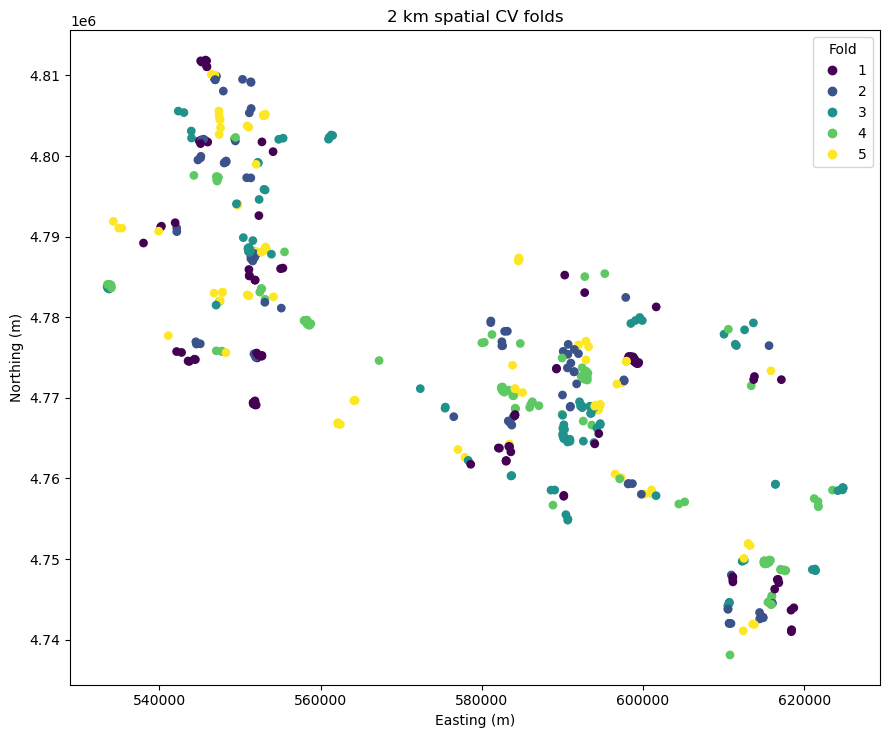

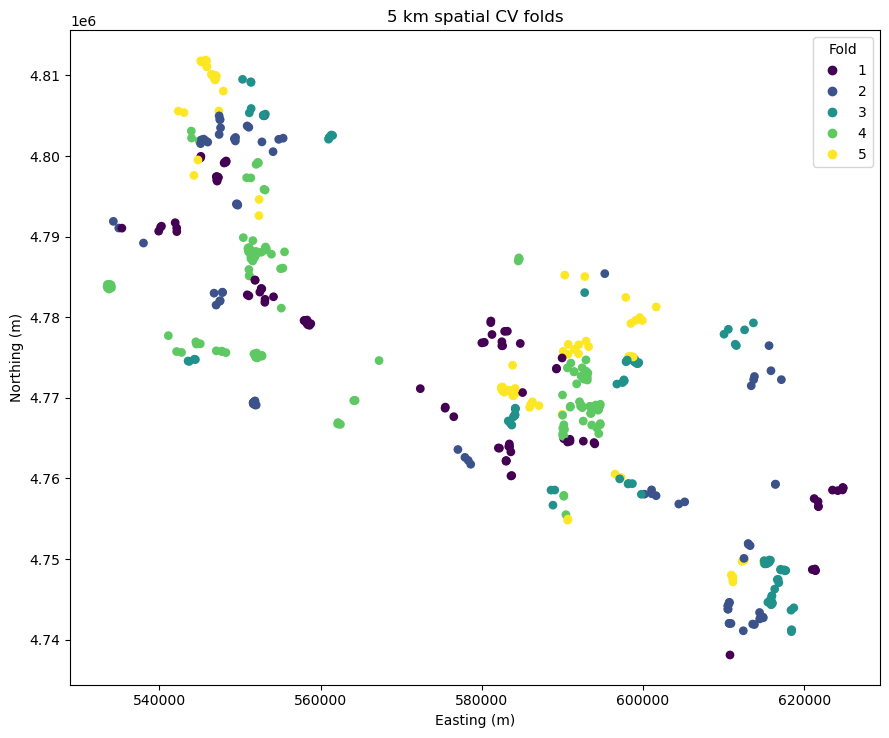

In [10]:
# =============================================================================
# 4. FOLD MAPS
# =============================================================================

for block_size in BLOCK_SIZES_M:

    subset = fold_assignments.loc[
        fold_assignments[
            "block_size_m"
        ].eq(
            block_size
        )
    ].copy()


    fig, ax = plt.subplots(
        figsize=(
            9,
            8,
        )
    )


    scatter = ax.scatter(
        subset[
            "Easting"
        ],
        subset[
            "Northing"
        ],
        c=subset[
            "fold"
        ],
        s=28,
    )


    ax.set_title(
        f"{block_size // 1000} km spatial CV folds"
    )

    ax.set_xlabel(
        "Easting (m)"
    )

    ax.set_ylabel(
        "Northing (m)"
    )

    ax.set_aspect(
        "equal"
    )


    legend = ax.legend(
        *scatter.legend_elements(),
        title="Fold",
        loc="best",
    )


    fig.tight_layout()


    fig.savefig(
        OUTPUT_DIR
        / f"spatial_folds_{block_size}m.png",
        dpi=250,
        bbox_inches="tight",
    )


    plt.show()

    plt.close(
        fig
    )

## 5. Models

The model definitions match the previous comparison notebook.  
By default only the random forest is run because it is the current mapping model and the representation comparison is the main question.

Set `RUN_ALL_MODELS = True` in Cell 0 to additionally run elastic-net multinomial logistic regression and Extra Trees.

In [11]:
# =============================================================================
# 5. MODEL DEFINITIONS
# =============================================================================

MODELS = {
    "elastic_net_logistic": Pipeline(
        [
            (
                "scale",
                StandardScaler(),
            ),
            (
                "model",
                LogisticRegression(
                    solver="saga",
                    penalty="elasticnet",
                    l1_ratio=0.5,
                    C=1.0,
                    class_weight="balanced",
                    max_iter=10000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "extra_trees": ExtraTreesClassifier(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced",
        bootstrap=False,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}


if RUN_ALL_MODELS:

    ACTIVE_MODELS = MODELS

else:

    ACTIVE_MODELS = {
        MODEL_FOR_PRIMARY_COMPARISON:
            MODELS[
                MODEL_FOR_PRIMARY_COMPARISON
            ]
    }


print(
    "Models to run:",
    list(
        ACTIVE_MODELS
    ),
)

Models to run: ['random_forest']


## 6. Run paired spatial cross-validation

Each representation is evaluated on the **same held-out observations** for a given block size and fold.

Primary metrics:

- accuracy;
- balanced accuracy;
- macro F1.

Pooled out-of-fold predictions are also retained for classwise diagnostics.

In [12]:
# =============================================================================
# 6. RUN SPATIAL CV
# =============================================================================

def score_predictions(
    y_true,
    y_pred,
):

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),

        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=VEG_CLASSES,
            average="macro",
            zero_division=0,
        ),
    }


fold_metric_records = []
prediction_records = []


for block_size in BLOCK_SIZES_M:

    splits = SPATIAL_SPLITS[
        block_size
    ][
        "splits"
    ]


    for representation, X in REPRESENTATIONS.items():

        for model_name, template in ACTIVE_MODELS.items():

            for fold, (
                train_idx,
                test_idx,
            ) in enumerate(
                splits,
                start=1,
            ):

                fitted = clone(
                    template
                )

                fitted.fit(
                    X[
                        train_idx
                    ],
                    y[
                        train_idx
                    ],
                )


                pred = fitted.predict(
                    X[
                        test_idx
                    ]
                ).astype(
                    str
                )


                scores = score_predictions(
                    y[
                        test_idx
                    ],
                    pred,
                )


                fold_metric_records.append(
                    {
                        "block_size_m": block_size,
                        "fold": fold,
                        "representation": representation,
                        "model": model_name,
                        "n_train": len(
                            train_idx
                        ),
                        "n_test": len(
                            test_idx
                        ),
                        **scores,
                    }
                )


                for local_pos, obs_idx in enumerate(
                    test_idx
                ):

                    prediction_records.append(
                        {
                            "block_size_m": block_size,
                            "fold": fold,
                            "representation": representation,
                            "model": model_name,
                            "PlotID": analysis.iloc[
                                obs_idx
                            ][
                                "PlotID"
                            ],
                            "Year": int(
                                analysis.iloc[
                                    obs_idx
                                ][
                                    "Year"
                                ]
                            ),
                            "parent_cluster": int(
                                analysis.iloc[
                                    obs_idx
                                ][
                                    "parent_cluster"
                                ]
                            ),
                            "y_true": y[
                                obs_idx
                            ],
                            "y_pred": pred[
                                local_pos
                            ],
                        }
                    )


fold_metrics = pd.DataFrame(
    fold_metric_records
)

oof_predictions = pd.DataFrame(
    prediction_records
)


fold_metrics.to_csv(
    OUTPUT_DIR
    / "spatialCV_fold_metrics.csv",
    index=False,
)

oof_predictions.to_csv(
    OUTPUT_DIR
    / "spatialCV_OOF_predictions.csv",
    index=False,
)


print(
    "Fold-level metrics:"
)

display(
    fold_metrics.round(
        4
    )
)

Fold-level metrics:


,block_size_m,fold,representation,model,n_train,n_test,accuracy,balanced_accuracy,macro_f1
0,2000,1,z,random_forest,385,94,0.4362,0.3611,0.3314
1,2000,2,z,random_forest,389,90,0.4333,0.3963,0.3654
2,2000,3,z,random_forest,377,102,0.4216,0.3576,0.3598
3,2000,4,z,random_forest,373,106,0.4340,0.3725,0.3688
4,2000,5,z,random_forest,392,87,0.4483,0.3938,0.3757
5,2000,1,polaris_18d,random_forest,385,94,0.1277,0.0954,0.0828
6,2000,2,polaris_18d,random_forest,389,90,0.2222,0.1974,0.1826
7,2000,3,polaris_18d,random_forest,377,102,0.1863,0.1902,0.1625
8,2000,4,polaris_18d,random_forest,373,106,0.2075,0.1380,0.1305
9,2000,5,polaris_18d,random_forest,392,87,0.1379,0.1136,0.1039


## 7. Pooled OOF metrics

Pooling the held-out predictions across all five folds gives one spatially out-of-fold prediction for every observation at each block size.

This is the cleanest direct comparison among Z, 18D POLARIS, and 7D POLARIS.

In [13]:
# =============================================================================
# 7. POOLED OOF METRICS
# =============================================================================

pooled_records = []


for (
    block_size,
    representation,
    model_name,
), group in oof_predictions.groupby(
    [
        "block_size_m",
        "representation",
        "model",
    ],
    sort=True,
):

    scores = score_predictions(
        group[
            "y_true"
        ].to_numpy(),
        group[
            "y_pred"
        ].to_numpy(),
    )


    pooled_records.append(
        {
            "block_size_m": block_size,
            "representation": representation,
            "model": model_name,
            "n": len(
                group
            ),
            **scores,
        }
    )


pooled_metrics = pd.DataFrame(
    pooled_records
)


pooled_metrics.to_csv(
    OUTPUT_DIR
    / "spatialCV_pooled_metrics.csv",
    index=False,
)


display(
    pooled_metrics.sort_values(
        [
            "block_size_m",
            "model",
            "macro_f1",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    ).round(
        4
    )
)

,block_size_m,representation,model,n,accuracy,balanced_accuracy,macro_f1
4,2000,z_plus_polaris_7d,random_forest,479,0.4363,0.3837,0.3851
2,2000,z,random_forest,479,0.4342,0.3838,0.3813
3,2000,z_plus_polaris_18d,random_forest,479,0.4259,0.3789,0.3805
1,2000,polaris_7d,random_forest,479,0.1879,0.1722,0.1696
0,2000,polaris_18d,random_forest,479,0.1775,0.1534,0.1494
8,5000,z_plus_polaris_18d,random_forest,479,0.4134,0.3788,0.3783
7,5000,z,random_forest,479,0.4008,0.3557,0.3414
9,5000,z_plus_polaris_7d,random_forest,479,0.3862,0.3483,0.3369
5,5000,polaris_18d,random_forest,479,0.1608,0.1724,0.1670
6,5000,polaris_7d,random_forest,479,0.1336,0.1222,0.1211


## 8. Direct representation deltas

Two comparisons matter:

### Soil contribution relative to Z

\[
\Delta_{18}=M(Z+P_{18})-M(Z)
\]

\[
\Delta_{7}=M(Z+P_{7})-M(Z)
\]

### Condensed representation versus original representation

\[
\Delta_{7-18}
=
M(Z+P_7)-M(Z+P_{18}).
\]

Because the folds and observations are identical, these are paired representation comparisons.

In [14]:
# =============================================================================
# 8. REPRESENTATION DELTAS
# =============================================================================

PRIMARY = pooled_metrics.loc[
    pooled_metrics[
        "model"
    ].eq(
        MODEL_FOR_PRIMARY_COMPARISON
    )
].copy()


metric_names = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
]


delta_records = []


for block_size in BLOCK_SIZES_M:

    x = PRIMARY.loc[
        PRIMARY[
            "block_size_m"
        ].eq(
            block_size
        )
    ].set_index(
        "representation"
    )


    required = [
        "z",
        "z_plus_polaris_18d",
        "z_plus_polaris_7d",
    ]


    missing = [
        rep
        for rep in required
        if rep not in x.index
    ]

    if missing:
        raise KeyError(
            f"Missing representations for {block_size} m: {missing}"
        )


    for metric in metric_names:

        z = x.loc[
            "z",
            metric,
        ]

        p18 = x.loc[
            "z_plus_polaris_18d",
            metric,
        ]

        p7 = x.loc[
            "z_plus_polaris_7d",
            metric,
        ]


        delta_records.append(
            {
                "block_size_m": block_size,
                "metric": metric,
                "z": z,
                "z_plus_18d": p18,
                "z_plus_7d": p7,
                "gain_18d_over_z": (
                    p18
                    - z
                ),
                "gain_7d_over_z": (
                    p7
                    - z
                ),
                "delta_7d_minus_18d": (
                    p7
                    - p18
                ),
            }
        )


representation_deltas = pd.DataFrame(
    delta_records
)


representation_deltas.to_csv(
    OUTPUT_DIR
    / "spatialCV_representation_deltas.csv",
    index=False,
)


print(
    "Random-forest representation comparison:"
)

display(
    representation_deltas.round(
        4
    )
)

Random-forest representation comparison:


,block_size_m,metric,z,z_plus_18d,z_plus_7d,gain_18d_over_z,gain_7d_over_z,delta_7d_minus_18d
0,2000,accuracy,0.4342,0.4259,0.4363,-0.0084,0.0021,0.0104
1,2000,balanced_accuracy,0.3838,0.3789,0.3837,-0.0049,-0.0001,0.0048
2,2000,macro_f1,0.3813,0.3805,0.3851,-0.0007,0.0039,0.0046
3,5000,accuracy,0.4008,0.4134,0.3862,0.0125,-0.0146,-0.0271
4,5000,balanced_accuracy,0.3557,0.3788,0.3483,0.0231,-0.0074,-0.0305
5,5000,macro_f1,0.3414,0.3783,0.3369,0.0368,-0.0045,-0.0413


## 9. Fold-wise paired 7D − 18D differences

The pooled result is the main score, but fold-wise paired differences reveal whether a gain is geographically consistent or driven by one region.

In [15]:
# =============================================================================
# 9. FOLD-WISE PAIRED DIFFERENCES
# =============================================================================

rf_fold = fold_metrics.loc[
    fold_metrics[
        "model"
    ].eq(
        MODEL_FOR_PRIMARY_COMPARISON
    )
].copy()


paired_records = []


for block_size in BLOCK_SIZES_M:

    for fold in range(
        1,
        N_SPLITS + 1,
    ):

        x = rf_fold.loc[
            rf_fold[
                "block_size_m"
            ].eq(
                block_size
            )
            & rf_fold[
                "fold"
            ].eq(
                fold
            )
        ].set_index(
            "representation"
        )


        for metric in metric_names:

            paired_records.append(
                {
                    "block_size_m": block_size,
                    "fold": fold,
                    "metric": metric,
                    "delta_7d_minus_18d": (
                        x.loc[
                            "z_plus_polaris_7d",
                            metric,
                        ]
                        -
                        x.loc[
                            "z_plus_polaris_18d",
                            metric,
                        ]
                    ),
                }
            )


paired_fold_deltas = pd.DataFrame(
    paired_records
)


paired_summary = (
    paired_fold_deltas
    .groupby(
        [
            "block_size_m",
            "metric",
        ],
        as_index=False,
    )
    .agg(
        mean_delta=(
            "delta_7d_minus_18d",
            "mean",
        ),
        median_delta=(
            "delta_7d_minus_18d",
            "median",
        ),
        min_delta=(
            "delta_7d_minus_18d",
            "min",
        ),
        max_delta=(
            "delta_7d_minus_18d",
            "max",
        ),
        n_folds_7d_better=(
            "delta_7d_minus_18d",
            lambda s: int(
                (
                    s > 0
                ).sum()
            ),
        ),
    )
)


paired_fold_deltas.to_csv(
    OUTPUT_DIR
    / "spatialCV_foldwise_7d_minus_18d.csv",
    index=False,
)

paired_summary.to_csv(
    OUTPUT_DIR
    / "spatialCV_foldwise_7d_minus_18d_summary.csv",
    index=False,
)


display(
    paired_summary.round(
        4
    )
)

,block_size_m,metric,mean_delta,median_delta,min_delta,max_delta,n_folds_7d_better
0,2000,accuracy,0.0115,0.0000,-0.0189,0.0638,2
1,2000,balanced_accuracy,0.0102,-0.0020,-0.0107,0.0520,2
2,2000,macro_f1,0.0032,-0.0061,-0.0158,0.0504,2
3,5000,accuracy,-0.0302,-0.0256,-0.0667,0.0074,1
4,5000,balanced_accuracy,-0.0371,-0.0090,-0.1293,0.0234,1
5,5000,macro_f1,-0.0288,-0.0185,-0.1235,0.0448,1


## 10. Classwise RF performance

This checks whether one representation improves the overall score by helping the same classes repeatedly, or merely trades errors among parent states.

In [16]:
# =============================================================================
# 10. CLASSWISE PERFORMANCE
# =============================================================================

class_records = []


rf_oof = oof_predictions.loc[
    oof_predictions[
        "model"
    ].eq(
        MODEL_FOR_PRIMARY_COMPARISON
    )
].copy()


for (
    block_size,
    representation,
), group in rf_oof.groupby(
    [
        "block_size_m",
        "representation",
    ]
):

    y_true = group[
        "y_true"
    ].to_numpy()

    y_pred = group[
        "y_pred"
    ].to_numpy()


    precision = precision_score(
        y_true,
        y_pred,
        labels=VEG_CLASSES,
        average=None,
        zero_division=0,
    )

    recall = recall_score(
        y_true,
        y_pred,
        labels=VEG_CLASSES,
        average=None,
        zero_division=0,
    )

    f1 = f1_score(
        y_true,
        y_pred,
        labels=VEG_CLASSES,
        average=None,
        zero_division=0,
    )


    supports = np.array(
        [
            np.sum(
                y_true
                == cls
            )
            for cls in VEG_CLASSES
        ],
        dtype=int,
    )


    for code, p, r, f, n in zip(
        VEG_PARENT_CODES,
        precision,
        recall,
        f1,
        supports,
    ):

        class_records.append(
            {
                "block_size_m": block_size,
                "representation": representation,
                "parent_cluster": code,
                "precision": p,
                "recall": r,
                "f1": f,
                "support": n,
            }
        )


classwise_metrics = pd.DataFrame(
    class_records
)


classwise_metrics.to_csv(
    OUTPUT_DIR
    / "spatialCV_RF_classwise_metrics.csv",
    index=False,
)


for block_size in BLOCK_SIZES_M:

    print(
        f"\n{'=' * 80}"
    )

    print(
        f"RF classwise F1 — {block_size // 1000} km blocks"
    )

    display(
        classwise_metrics.loc[
            classwise_metrics[
                "block_size_m"
            ].eq(
                block_size
            )
            & classwise_metrics[
                "representation"
            ].isin(
                [
                    "z",
                    "z_plus_polaris_18d",
                    "z_plus_polaris_7d",
                ]
            )
        ]
        .pivot(
            index="parent_cluster",
            columns="representation",
            values="f1",
        )
        .round(
            3
        )
    )


RF classwise F1 — 2 km blocks


representation,z,z_plus_polaris_18d,z_plus_polaris_7d
parent_cluster,,,
1,0.493,0.468,0.461
2,0.365,0.319,0.333
3,0.497,0.529,0.532
4,0.516,0.511,0.520
5,0.416,0.410,0.460
6,0.304,0.253,0.309
7,0.375,0.387,0.300
8,0.083,0.167,0.167



RF classwise F1 — 5 km blocks


representation,z,z_plus_polaris_18d,z_plus_polaris_7d
parent_cluster,,,
1,0.338,0.366,0.345
2,0.239,0.175,0.241
3,0.500,0.488,0.435
4,0.508,0.561,0.508
5,0.479,0.484,0.464
6,0.244,0.289,0.227
7,0.423,0.366,0.395
8,0.000,0.296,0.080


## 11. Interpretation criteria

Do **not** select the 7D representation merely because it wins one scalar metric in one block design.

Evidence favoring the condensed representation is strongest if:

1. \(Z+P_7\) exceeds \(Z+P_{18}\) at **both 2 km and 5 km**;
2. the advantage appears in balanced accuracy and macro F1, not only raw accuracy;
3. most spatial folds have a positive paired \(7D-18D\) difference;
4. gains are not caused by severe deterioration in one or two parent states;
5. the 7D representation retains or improves the earlier grouped-OOF / LOYO behavior.

If 7D and 18D are effectively tied, prefer the 7D representation on parsimony grounds: seven ecologically broader predictors are easier to interpret and less redundant than eighteen depth-explicit texture predictors.

The 2 km and 5 km scores answer somewhat different questions. A substantial performance drop at 5 km would indicate that local spatial dependence is contributing materially to the 2 km result.